   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  
(500, 6)


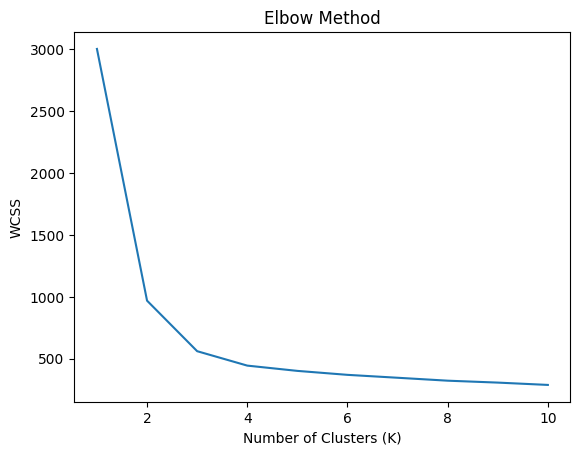


Data with Cluster:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  cluster  
0                         6        2  
1                         3        0  
2                         4        2  
3                         2        0  
4                         1        0  

Cluster Centers:
        age  annual_spend  visits_per_month  basket_size  \
0 -1.094595     -1.036122          1.114284    -0.934278   
1  1.132214      1.235574         -1.106680     1.253260   
2 -0.004449     -0.168055         -0.041370    -0.290670   

   days_since_last

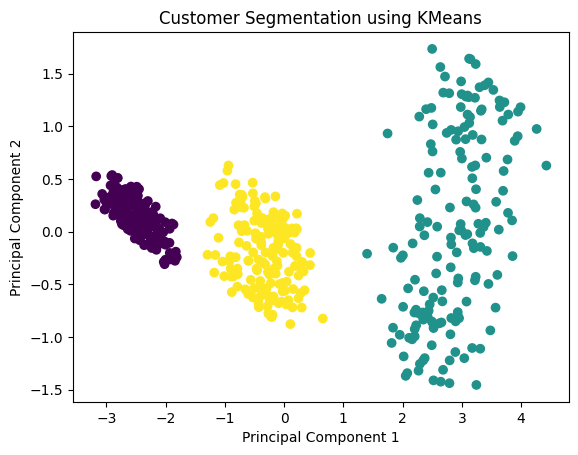

In [1]:
# -----------------------
# Import libraries
# -----------------------
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# -----------------------
# Load dataset
# -----------------------
df = pd.read_csv('../data/q2_customers.csv')

print(df.head())
print(df.shape)

# -----------------------
# Scaling
# -----------------------
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# -----------------------
# Elbow Method
# -----------------------
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, n_init=5, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.show()

# -----------------------
# KMeans (choose K = 3)
# -----------------------
kmeans = KMeans(n_clusters=3, n_init=5, random_state=42)

clusters = kmeans.fit_predict(scaled_data)

# Add cluster column
df['cluster'] = clusters

print("\nData with Cluster:")
print(df.head())

# -----------------------
# Cluster Centers
# -----------------------
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])

print("\nCluster Centers:")
print(centroids)

# -----------------------
# PCA (Dimensionality Reduction)
# -----------------------
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

print("\nExplained Variance Ratio:", pca.explained_variance_ratio_)

# -----------------------
# Cluster Visualization
# -----------------------
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using KMeans")

plt.show()

K-Means clustering was used to divide customers into three groups.

Cluster 0 represents customers with lower engagement and spending.

Cluster 1 represents moderate customers with average behavior.

Cluster 2 represents high-value customers with frequent visits and higher spending.

PCA was used to reduce the data to two dimensions for visualization.